In [12]:
import polars as pl
import pandas as pd

In [ ]:
#import the annotation table of the mgf used as input in the FASST search
annotation_table = pl.read_csv("/.../Carnitine_library_2025_testing_annotation_table.tsv", separator="\t", ignore_errors=True)


In [ ]:
#import matches after the raw_cosine calculation
matches = pl.read_csv("/.../matches_cosine_calculation_output.tsv", separator="\t",
                      ignore_errors=True)

#merge with annotation table
matches = matches.join(annotation_table, on="Scan", how="left")

#calculate deltas
matches = matches.with_columns(
    (pl.col("precursor_mz") - 162.1125).alias("delta")
)

matches = matches.with_columns(
    pl.col("delta").round(2).alias("delta_round")
)

#filter for only matches with cosine_raw >= 0.7
matches = matches.filter(matches["cosine_raw"] >= 0.7)

#create a column scan_USI
matches = matches.with_columns(
    (pl.col("Scan").cast(pl.Utf8) + "_" + pl.col("USI")).alias("scan_USI")
)


# FoodMASST

In [ ]:
#import foodmasst
foodmasst = pl.read_csv('/.../food.tsv', separator='\t', ignore_errors=True)

#create scan_USI
foodmasst = foodmasst.with_columns(
    (pl.col("Scan").cast(pl.Utf8) + "_" + pl.col("USI")).alias("scan_USI")
)

#merge with matches.tsv since it has info on the raw cosine, deltas, etc
foodmasst_merged = foodmasst.join(
    matches.select(["scan_USI", "cosine_raw", "precursor_mz", "delta", "delta_round"]),
    on="scan_USI",
    how="left"
)

#filter for only matches with cosine_raw >= 0.7
foodmasst_merged = foodmasst_merged.filter(foodmasst_merged["cosine_raw"] >= 0.7)

#convert to pandas
foodmasst_merged = foodmasst_merged.to_pandas()

#and finally let's add another annotation column with simplified names (putative explanation if available, or CAR with deltas)
annotation_delta_round = pd.read_csv('/.../Carnitines_library_2025_testing_V2_MassQL_only_annotation_table_delta_round.tsv', sep='\t')
annotation_delta_round = annotation_delta_round.rename(columns={'scans':'Scan'})

foodmasst_merged = pd.merge(foodmasst_merged, annotation_delta_round[['Scan', 'annotation_delta_round']], on='Scan', how='left')

#now let's remove compounds that appear just one or two times
foodmasst_merged = foodmasst_merged.groupby('annotation_delta_round').filter(lambda x: len(x) >= 3)


In [ ]:
#import food ontology
food_ontology = pd.read_csv('/.../gfop_ontology.txt', sep='\t')

#and merge with foodMASST results
foodmasst_merged = pd.merge(foodmasst_merged, food_ontology, on='node_id', how='left')

foodmasst_merged['sample_type_group1'].value_counts()

sample_type_group1
animal        309768
plant          62339
fungi           5253
algae            172
mineral            7
supplement         4
water              1
Name: count, dtype: int64

In [17]:
#keep only columns of interest and drop duplicates
foodmasst_merged_deltas = foodmasst_merged[['annotation_delta_round', 'sample_type_group1', 'sample_type_group2', 'sample_type_group3', 'sample_type_group4', 'sample_type_group5']].drop_duplicates()

#keep only animal, plants and fungi in sample_type_group1 - the most frequent ones
foodmasst_merged_deltas_filtered = foodmasst_merged_deltas[foodmasst_merged_deltas['sample_type_group1'].isin(['animal', 'plant', 'fungi'])] 


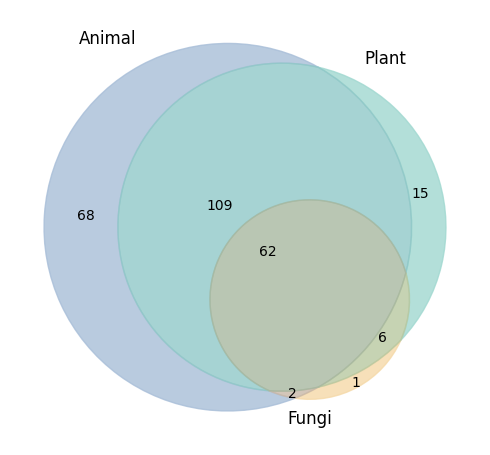

In [ ]:
#plot

import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Get sets of annotation_delta_round for each group
animal = set(foodmasst_merged_deltas_filtered[foodmasst_merged_deltas_filtered['sample_type_group1'] == 'animal']['annotation_delta_round'])
plant  = set(foodmasst_merged_deltas_filtered[foodmasst_merged_deltas_filtered['sample_type_group1'] == 'plant']['annotation_delta_round'])
fungi  = set(foodmasst_merged_deltas_filtered[foodmasst_merged_deltas_filtered['sample_type_group1'] == 'fungi']['annotation_delta_round'])

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
v = venn3([animal, plant, fungi], set_labels=('Animal', 'Plant', 'Fungi'), ax=ax)

# Purple shades for each region
colors = {
    '100': '#A8BED8',  # Animal only - soft blue
    '010': '#A0D8D0',  # Plant only - soft teal
    '001': '#F5D9A8',  # Fungi only - warm peach
    '110': '#90C8C8',  # Animal + Plant - blue-teal overlap
    '101': '#C8B8A8',  # Animal + Fungi - blue-peach overlap (warm grey)
    '011': '#B8C8A0',  # Plant + Fungi - teal-peach overlap (sage)
    '111': '#A8B8A0',  # All three - muted sage grey
}
for region_id, color in colors.items():
    patch = v.get_patch_by_id(region_id)
    if patch:
        patch.set_color(color)
        patch.set_alpha(0.8)

plt.tight_layout()
plt.savefig('/.../foodmasst_ontology_distribution_venndiagram.pdf')
plt.show()